### simple logistic regression


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [2]:
df = pd.read_csv('simple_loan.csv')

In [3]:
df.head(10)

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved
1,45,Female,Teacher,Master's,Single,62000,680,Approved
2,28,Male,Student,High School,Single,25000,590,Denied
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved
5,24,Female,Nurse,Associate's,Single,48000,640,Denied
6,42,Male,Lawyer,Doctoral,Married,120000,790,Approved
7,29,Female,Artist,Bachelor's,Single,38000,620,Denied
8,37,Male,IT,Master's,Married,92000,750,Approved
9,48,Female,Doctor,Doctoral,Married,180000,820,Approved


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              61 non-null     int64 
 1   gender           61 non-null     object
 2   occupation       61 non-null     object
 3   education_level  61 non-null     object
 4   marital_status   61 non-null     object
 5   income           61 non-null     int64 
 6   credit_score     61 non-null     int64 
 7   loan_status      61 non-null     object
dtypes: int64(3), object(5)
memory usage: 3.9+ KB


In [6]:
has_nulls = df.isnull().values.any()
print(has_nulls)

False


### defining feature  x and target y

In [22]:
x= df.drop('loan_status', axis=1)
y=df['loan_status']

In [23]:
x.dtypes

age                 int64
gender             object
occupation         object
education_level    object
marital_status     object
income              int64
credit_score        int64
dtype: object

In [24]:
num_columns=x.select_dtypes(include=np.number).columns
cat_columns=x.select_dtypes(include='object').columns

In [25]:
num_columns,cat_columns

(Index(['age', 'income', 'credit_score'], dtype='object'),
 Index(['gender', 'occupation', 'education_level', 'marital_status'], dtype='object'))

In [26]:
y=y.map({ 'Denied' :0,'Approved':1})

### encoding the categorical features to numerical values

In [27]:
encoder = OneHotEncoder(sparse_output=False, drop='first') #drop the first category to avoid multicollinearity
encoder_cat = encoder.fit_transform(x[cat_columns])
encoder_cat

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 1.],
       [1., 0., 0., ..., 1., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 1.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [29]:
encoder_cat_df = pd.DataFrame(encoder_cat, columns=encoder.get_feature_names_out(cat_columns))#create a dataframe from the encoded categorical features with appropriate column names
encoder_cat_df

,gender_Male,occupation_Analyst,occupation_Architect,occupation_Artist,occupation_Banker,occupation_Chef,occupation_Consultant,occupation_Dentist,occupation_Designer,occupation_Doctor,...,occupation_Student,occupation_Stylist,occupation_Teacher,occupation_Veterinarian,occupation_Writer,education_level_Bachelor's,education_level_Doctoral,education_level_High School,education_level_Master's,marital_status_Single
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
57,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
58,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
59,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [30]:
x_final = pd.concat([x[num_columns].reset_index(drop=True), encoder_cat_df.reset_index(drop=True)], axis=1) #combine the numerical features with the encoded categorical features to create the   final feature set
x_train, x_test, y_train, y_test = train_test_split(x_final, y, test_size=0.2, random_state=42) #split the data into training and testing sets

In [31]:
model = LogisticRegression(max_iter=1000)

In [32]:
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [33]:
y_pred = model.predict(x_test)

In [34]:
accuracy = (y_pred == y_test).mean() #calculate the accuracy of the model by comparing the predicted values with the actual values in the test set
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


In [35]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[4 0]
 [0 9]]


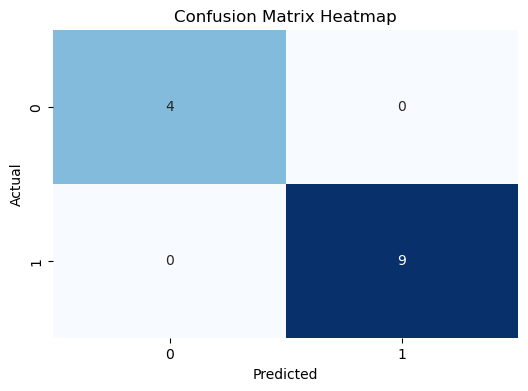

In [36]:
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()